# ENGINEERING MATHEMATICS: DIFFERENTIAL EQUATIONS — 0916

## 1.3 Differential Equations as Mathematical Models

### Motion with resistance

Position $x(t)$, velocity $v(t)$, and acceleration $a(t)$ satisfy
$$ v = x', \qquad a = v' = x''. $$
With an applied force $F$ and resistance proportional to velocity, Newton's second law gives
$$ F - \beta v = ma\quad \Longrightarrow \quad mx'' + \beta x' = F. $$

### Population growth

If the rate of increase is proportional to the current population,

$$ A' = kA. $$

For constant $k$, the solution is $A(t) = A(0)e^{kt}$.

### Newton's law of cooling

For a constant ambient temperature $T_m$,

$$ T' = k(T - T_m). $$

With this sign convention, cooling requires $k<0$.

Equivalently, write $T' = -\lambda(T - T_m)$ with $\lambda>0$.

$$ T(t) = T_m + [T(0) - T_m]e^{-\lambda t}. $$

### From integration to differential equations

If $A' = f(t)$, we can integrate directly.

For example,

$$ A' = \frac1t\quad \Longrightarrow \quad A = \ln|t| + C\qquad(t \ne 0), $$

$$ A' = \frac1{t^2 + 4}\quad \Longrightarrow \quad A = \frac12\arctan\frac t2 + C. $$

When the right-hand side also contains the unknown function, as in $A' = kA$, or when higher derivatives appear, we need additional solution methods.

## 2.1 Draw a Solution

### Direction fields

For $y' = f(x, y)$, draw a short line segment of slope $f(x_0, y_0)$ at each sampled point $(x_0, y_0)$.

Solution curves follow these directions.

**Example 1: $y' = 0.2xy$.**

- The slope is zero when $x = 0$ or $y = 0$.
- The slope is positive when $xy>0$ and negative when $xy<0$.
- The general solution is $y = Ce^{0.1x^2}$.

The conditions $y(0) = 2$ and $y(0) = -1$ select the highlighted curves below.
The dots mark their initial values; the gray segments show the prescribed slopes.

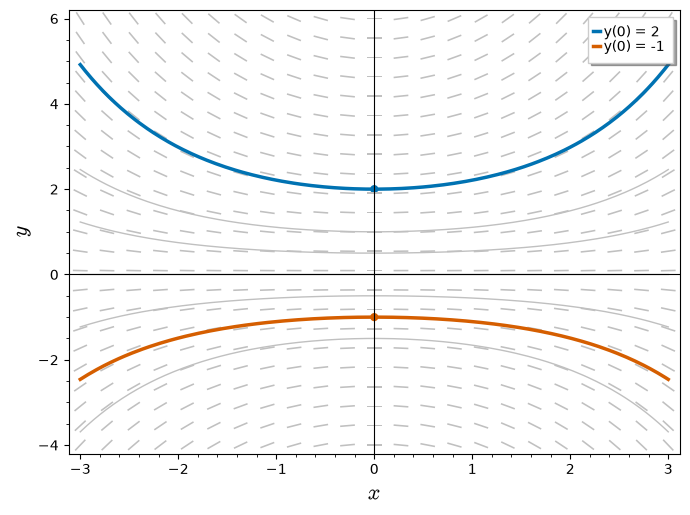

In [ ]:
sx, sy = SR.var('sx sy')
field_xy = plot_slope_field(sx*sy/5, (sx, -3, 3), (sy, -4, 6),
                           plot_points=23, color='silver')
for initial in [-1.5, -0.5, 0, 0.5, 1]:
    field_xy += plot(initial*exp(sx**2/10), (sx, -3, 3),
                     color='silver', thickness=1)
for initial, color in [(2, '#0072B2'), (-1, '#D55E00')]:
    field_xy += plot(initial*exp(sx**2/10), (sx, -3, 3),
                     color=color, thickness=2.5, legend_label=f'y(0) = {initial}')
    field_xy += point((0, initial), color=color, size=35)
field_xy.show(xmin=-3, xmax=3, ymin=-4, ymax=6, axes_labels=['$x$', '$y$'], figsize=7)

**Example 2: $y' = \sin y$.**

- The constant functions $y = k\pi$, with $k\in\mathbb Z$, are equilibrium solutions.
- For $y(0) = -3/2$, the initial slope is negative.

  As time moves forward, the solution approaches $-\pi$.

Direction fields reveal qualitative behavior even when an explicit formula is difficult to obtain.



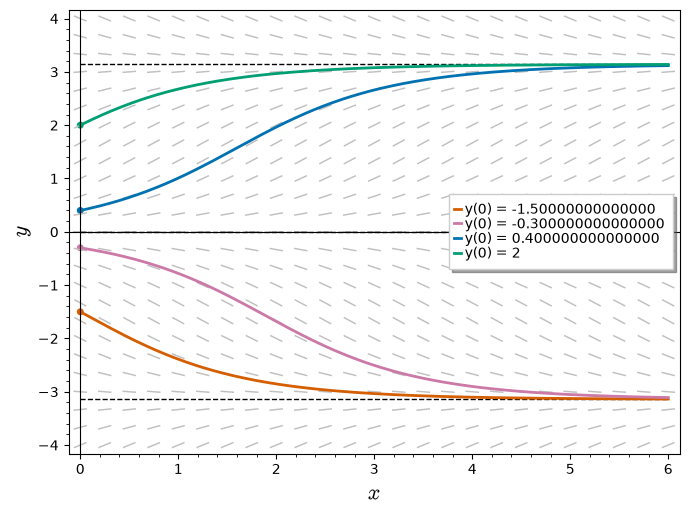

In [ ]:
field_sin = plot_slope_field(sin(sy), (sx, 0, 6), (sy, -4, 4),
                            plot_points=25, color='silver')
for level in [-pi, 0, pi]:
    field_sin += plot(level, (sx, 0, 6), color='black', linestyle='--')
for initial, color in [(-1.5, '#D55E00'), (-0.3, '#CC79A7'), (0.4, '#0072B2'), (2, '#009E73')]:
    curve = 2*arctan(tan(initial/2)*exp(sx))
    field_sin += plot(curve, (sx, 0, 6), color=color, thickness=2,
                      legend_label=f'y(0) = {initial}')
    field_sin += point((0, initial), color=color, size=25)
field_sin.show(xmin=0, xmax=6, ymin=-4, ymax=4, axes_labels=['$x$', '$y$'], figsize=7)

The dashed curves are the equilibria $y = -\pi$, $y = 0$, and $y = \pi$.
The orange curve starts at $-3/2$ and approaches $-\pi$.
Nearby curves move away from $0$ and toward $\pm\pi$ as $x$ increases.

The planar slope fields used here apply to scalar first-order equations.

Higher-order equations can be rewritten as first-order systems and studied using other tools.



### Lotka–Volterra: predator and prey

Let $p(t)$ and $q(t)$ be scaled prey and predator populations.
A dimensionless **Lotka–Volterra model** is
$$ p' = p(1 - q), \qquad q' = q(p - 1). $$
Prey grow when predators are scarce ($q < 1$).
Predators grow when prey are plentiful ($p > 1$).
The positive equilibrium is $(p, q) = (1, 1)$.

In the **phase plane**, each point represents both populations at one time.
The arrows give $(p', q')$; a solution traces a path following them.
The dashed lines $p = 1$ and $q = 1$ separate regions of population growth and decline.
Arrow lengths are rescaled for readability; their directions are preserved.

In [ ]:
prey, predator = SR.var('prey predator')
lv_rhs = [prey*(1 - predator), predator*(prey - 1)]
lv_times = [0.02*j for j in range(1501)]
lv_initials = [(1.2, 1.0), (1.6, 0.8), (2.3, 1.0)]
lv_colors = ['#009E73', '#0072B2', '#D55E00']
lv_solutions = [desolve_odeint(lv_rhs, initial, lv_times, [prey, predator],
                             rtol=1e-10, atol=1e-10) for initial in lv_initials]
speed = sqrt(lv_rhs[0]**2 + lv_rhs[1]**2 + 0.04)
lv_phase = plot_vector_field([component/speed for component in lv_rhs],
                            (prey, 0.05, 2.7), (predator, 0.05, 2.7),
                            plot_points=19, color='silver')

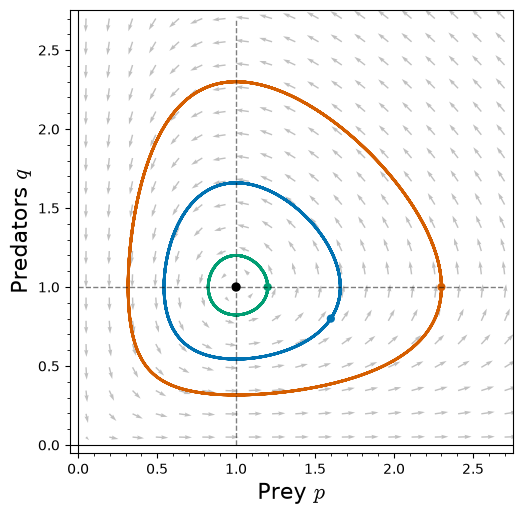

In [ ]:
for solution, initial, color in zip(lv_solutions, lv_initials, lv_colors):
    lv_phase += line(solution, color=color, thickness=2)
    lv_phase += point(initial, color=color, size=35)
lv_phase += line([(1, 0), (1, 2.7)], color='black', linestyle='--', alpha=0.5)
lv_phase += line([(0, 1), (2.7, 1)], color='black', linestyle='--', alpha=0.5)
lv_phase += point((1, 1), color='black', size=45)
lv_phase.show(xmin=0, xmax=2.7, ymin=0, ymax=2.7, aspect_ratio=1,
              axes_labels=['Prey $p$', 'Predators $q$'], figsize=7)

The colored trajectories circle the coexistence equilibrium counterclockwise.
In this idealized model, positive non-equilibrium trajectories are closed orbits:
the populations cycle rather than converge to $(1, 1)$.
The colored dots mark the starting populations; the black dot marks the equilibrium.

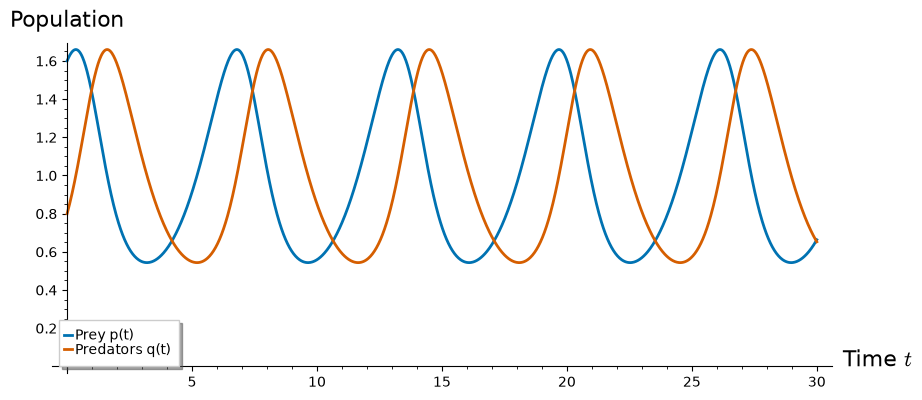

In [ ]:
lv_sample = lv_solutions[1]
lv_history = line(list(zip(lv_times, lv_sample[:, 0])), color='#0072B2',
                  thickness=2, legend_label='Prey p(t)')
lv_history += line(list(zip(lv_times, lv_sample[:, 1])), color='#D55E00',
                   thickness=2, legend_label='Predators q(t)')
lv_history.show(xmin=0, xmax=30, ymin=0, axes_labels=['Time $t$', 'Population'],
                figsize=[9, 4])

This time plot follows the blue phase-plane trajectory, starting at $(1.6, 0.8)$.
Prey reach their peak before predators do.
As predators become abundant, prey decline; the shortage of prey then reduces predators.

**Read the pictures:** At which line does each population stop increasing?
Relate each peak in the time plot to a crossing of a dashed line in the phase plane.

## Further Study: 2.6 Euler's Method


This section is not listed separately in the current weekly schedule.

Approximate the derivative by a difference quotient:

$$ \frac{y(x_{n + 1}) - y(x_n)}{x_{n + 1} - x_n} \approx f(x_n, y(x_n)). $$

With step size $h = x_{n + 1} - x_n$, the forward Euler method is

$$ \boxed{x_{n + 1} = x_n + h, \qquad y_{n + 1} = y_n + h f(x_n, y_n)}. $$



Here $y_n$ is a numerical approximation, usually different from the exact value $y(x_n)$.

Example: $y' = 0.2xy$, $y(0) = 2$, and $h = 0.1$.

$$ y_1 = 2 + 0.1(0.2\cdot0\cdot2) = 2, $$
$$ y_2 = 2 + 0.1(0.2\cdot0.1\cdot2) = 2.004. $$

Smaller step sizes generally improve accuracy, but the variation of the function and the stability of the method also matter.



Numerical methods are useful for computer simulation, at the cost of truncation and accumulated errors.



### Euler's method: comparing numerical errors

The example $y' = \sin x$, $y(0) = -1$ has the exact solution $y = -\cos x$.

The following code compares errors at $x = 10$ for different step sizes.

It uses only the Python standard library.

In [ ]:
from math import sin, cos

def euler(f, x0, y0, h, steps):
    x, y = x0, y0
    for i in range(steps):
        y += h * f(x, y)
        x = x0 + (i + 1) * h
    return x, y

for h in (1.0, 0.1, 0.01):
    x, y = euler(lambda x, y: sin(x), 0.0, -1.0, h, round(10 / h))
    exact = -cos(x)
    print(f"h={h:g}, x={x:g}, Euler={y:.8f}, Exact={exact:.8f}, Error={abs(y-exact):.8f}")


## Methods for Solving Differential Equations

A differential equation can be studied in several ways:

- **Graphically:** inspect slopes and solution curves.
- **Numerically:** approximate the solution at discrete points.
- **Analytically:** derive an explicit formula or an implicit relation.
- **By series:** represent the solution as a power series.
- **With matrices:** organize systems of equations.
- **With transforms:** use Laplace transforms, Fourier series, or Fourier transforms.

For first-order equations, useful analytic methods include direct integration,  
separation of variables, integrating factors for linear or exact equations,  
and substitutions for homogeneous equations, Bernoulli equations,  
or equations involving $Ax + By + c$.

Here we develop **separation of variables** and **linear integrating factors**.

## Direct Integration

If the derivative depends only on $x$,
$$ \frac{dy}{dx} = f(x), $$
then
$$ y(x) = \int f(x)\,dx = F(x) + C, \qquad F'(x) = f(x). $$
An indefinite integral represents a family of antiderivatives.

For an initial condition $y(x_0) = y_0$, use a definite integral:
$$ \boxed{y(x) = y_0 + \int_{x_0}^{x} f(t)\,dt.} $$
The variable $t$ is a dummy variable; $x$ is the upper limit.

For example,
$$ \int_{x_0}^{x} \cos t\,dt = \sin x - \sin x_0. $$
The lower limit fixes the constant.

### Integration and the chain rule

If $F'(x) = f(x)$ and $a \ne 0$, then
$$ \frac{d}{dx}F(ax) = af(ax), $$
so
$$ \int f(ax)\,dx = \frac1a F(ax) + C. $$
For definite integrals,
$$ \int_{x_0}^{x} f(at)\,dt = \frac{F(ax) - F(ax_0)}a. $$

## 2.2 Separable Variables

### Recognizing a separable equation

A first-order equation is **separable** if it can be written as
$$ \frac{dy}{dx} = g(x)h(y). $$
The right-hand side is a product of a function of $x$ and a function of $y$.

For example,
$$ y' = \cos x\,e^{x + 2y} = (e^x\cos x)e^{2y} $$
is separable. The expression $x + y$ is not directly such a product.

### Separation of variables: the procedure

On a region where $h(y) \ne 0$, separate and integrate:
$$ \frac{dy}{h(y)} = g(x)\,dx, $$
$$ \int \frac{dy}{h(y)} = \int g(x)\,dx. $$
If $H'(y) = 1/h(y)$ and $G'(x) = g(x)$, this gives
$$ \boxed{H(y) = G(x) + C.} $$
Two integration constants combine into one.

Then:

1. Use the initial condition, if one is given.
2. Check constant solutions before accepting the answer as complete.
3. Choose the appropriate branch if solving explicitly for $y$.
4. State an interval on which the original equation is defined.
5. Differentiate and substitute to verify the result.

### Constant solutions

If $h(r) = 0$, then $y(x) = r$ satisfies
$$ y' = g(x)h(y), $$
because both sides vanish.

Dividing by $h(y)$ can remove these **equilibrium solutions**.  
Check them directly in the original equation.  
The PDF calls these constant solutions “singular solutions.”

### Example 1: $(1 + x)\,dy - y\,dx = 0$

For $x \ne -1$ and $y \ne 0$,
$$ \frac{dy}{y} = \frac{dx}{1 + x}, $$
$$ \ln|y| = \ln|1 + x| + C_1. $$
Absorb the signs and exponential constant into $C$:
$$ \boxed{y = C(1 + x).} $$
The constant solution $y = 0$ is included by taking $C = 0$.

The standard form $y' = y/(1 + x)$ is defined on intervals avoiding $x = -1$.

The original equation $(1 + x)y' - y = 0$ also makes sense at $x = -1$.  
The functions $C(1 + x)$ satisfy that original equation there as well.

### Example 2: choosing the branch with an initial condition

Solve
$$ y' = -\frac{x}{y}, \qquad y(4) = -3. $$
Separation gives
$$ y\,dy = -x\,dx, \qquad \frac{y^2}{2} = -\frac{x^2}{2} + C. $$
The initial condition gives $C = 25/2$, hence
$$ \boxed{x^2 + y^2 = 25.} $$

The initial value selects the lower semicircle:
$$ \boxed{y = -\sqrt{25 - x^2}, \qquad -5 < x < 5.} $$
The endpoints are excluded because the differential equation divides by $y$.

There is no constant solution on an open interval:  
$0 = -x/r$ cannot hold for every $x$ in such an interval.

### Example 3: $y' = y^2 - 4$

First record the equilibria:
$$ y^2 - 4 = 0 \quad\Longrightarrow\quad y = 2 \text{ or } y = -2. $$
For the other solutions, use partial fractions:
$$ \frac{1}{y^2 - 4} = \frac14\left(\frac1{y - 2} - \frac1{y + 2}\right). $$
Therefore,
$$ \frac14\ln\left|\frac{y - 2}{y + 2}\right| = x + C_1. $$

Exponentiating and solving for $y$ gives
$$ \frac{y - 2}{y + 2} = Ce^{4x}, $$
$$ \boxed{y = 2\frac{1 + Ce^{4x}}{1 - Ce^{4x}}.} $$
Use an interval on which the denominator is nonzero.  
Setting $C = 0$ includes $y = 2$; add $y = -2$ separately.

### Example 4: an implicit solution

Solve
$$ (e^{2y} - y)\cos x\,y' = e^y\sin 2x, \qquad y(0) = 0. $$
Near $x = 0$, divide by $e^y\cos x$ and use $\sin 2x = 2\sin x\cos x$:
$$ (e^y - ye^{-y})\,dy = 2\sin x\,dx. $$
Integration gives
$$ e^y + (y + 1)e^{-y} = -2\cos x + C. $$

Since $y(0) = 0$, we have $2 = -2 + C$, so
$$ \boxed{e^y + (y + 1)e^{-y} = 4 - 2\cos x.} $$
Check the antiderivative:
$$ \frac{d}{dy}\bigl[(y + 1)e^{-y}\bigr] = -ye^{-y}. $$
There is no constant solution, since $e^r\sin 2x$ cannot vanish on an open interval.

### Nonuniqueness: $y' = x\sqrt y$, $y(0) = 0$

For $y > 0$,
$$ \frac{dy}{\sqrt y} = x\,dx, \qquad 2\sqrt y = \frac{x^2}{2} + C. $$
One solution satisfying $y(0) = 0$ is
$$ y = \frac{x^4}{16}. $$
The constant solution $y = 0$ satisfies the same initial condition.

There are also solutions that remain at zero before leaving it.  
For any $b \le 0 \le a$,
$$ y(x) = \begin{cases}
(x^2 - b^2)^2/16, & x \le b, \\
0, & b < x < a, \\
(x^2 - a^2)^2/16, & x \ge a.
\end{cases} $$
At the joining points, both $y$ and $y'$ agree.  
On the outer intervals, $x^2 - b^2$ or $x^2 - a^2$ is nonnegative.

### When does an IVP have a unique solution?

Consider
$$ y' = f(x, y), \qquad y(x_0) = y_0. $$
If $f$ and $\partial f/\partial y$ are continuous on a rectangle  
containing $(x_0, y_0)$ in its interior, then the IVP has a unique solution  
on some interval $x_0 - h < x < x_0 + h$.

This is a **local** existence and uniqueness result.

For $f(x, y) = x\sqrt y$, the derivative
$$ \frac{\partial f}{\partial y} = \frac{x}{2\sqrt y} $$
is not continuous on a rectangle around $(0, 0)$;  
the real-valued function itself is only defined for $y \ge 0$.

The theorem does not guarantee uniqueness here.  
The distinct solutions above demonstrate that uniqueness actually fails.

### Solutions defined by integrals

The fundamental theorem of calculus gives
$$ \frac{d}{dx}\int_{x_0}^{x} g(t)\,dt = g(x) $$
when $g$ is continuous.

A definite integral is an exact way to describe a solution,  
even when an elementary antiderivative is unavailable.  
For example, $e^{-x^2}$ and $\sin(x^2)$ are elementary functions  
whose antiderivatives are not elementary.

### Example 5: a Gaussian integral

For
$$ y' = e^{-x^2}, \qquad y(3) = 5, $$
the solution is
$$ \boxed{y(x) = 5 + \int_3^x e^{-t^2}\,dt.} $$
Differentiation verifies the equation, and the integral vanishes at $x = 3$.

Define the **error function** and **complementary error function** by
$$ \operatorname{erf}(x) = \frac{2}{\sqrt\pi}\int_0^x e^{-t^2}\,dt, $$
$$ \operatorname{erfc}(x) = \frac{2}{\sqrt\pi}\int_x^\infty e^{-t^2}\,dt = 1 - \operatorname{erf}(x). $$
Then the same solution is
$$ y(x) = 5 + \frac{\sqrt\pi}{2}\bigl[\operatorname{erfc}(3) - \operatorname{erfc}(x)\bigr]. $$

### Practice habits for separable equations

- Know the common antiderivatives and practice partial fractions.
- Keep one arbitrary constant and simplify it carefully.
- Check equilibria lost when dividing.
- Keep track of signs, branches, and solution intervals.
- Cover the worked solution and solve the example again without hints.

## Appendix: Calculus Tools

A computer algebra system can help find antiderivatives and derivatives.  
The PDF illustrates online integral lookup and a few SymPy commands.

In a notebook, display the calculation and then verify it by differentiation.  
The following cells require **SymPy** in the Python kernel.

In [1]:
import sympy as sp
from IPython.display import display
x, y, t, C = sp.symbols('x y t C', real=True)

In [2]:
F = sp.integrate(1 / (4 + x**2), x)
display(F)
display(sp.diff(sp.cos(x**3), x))
display(sp.integrate(1 / x**2, (x, 1, 2)))
assert sp.simplify(sp.diff(F, x) - 1 / (4 + x**2)) == 0

atan(x/2)/2

-3*x**2*sin(x**3)

1/2

The results are
$$ \int\frac{dx}{4 + x^2} = \frac12\arctan\frac x2 + C, $$
$$ \frac{d}{dx}\cos(x^3) = -3x^2\sin(x^3), \qquad \int_1^2\frac{dx}{x^2} = \frac12. $$
SymPy returns an antiderivative without the arbitrary constant;  
include $C$ when writing the general solution of a differential equation.

## 2.3 Linear Equations

### Standard form

A first-order linear equation has the form
$$ a_1(x)y' + a_0(x)y = g(x). $$
On an interval where $a_1(x) \ne 0$, divide by $a_1(x)$:
$$ \boxed{y' + P(x)y = f(x),} $$
where $P = a_0/a_1$ and $f = g/a_1$.

The equation is **homogeneous** if $f$ is identically zero; otherwise it is **nonhomogeneous**.

### Homogeneous solution plus particular solution

Suppose $y_p$ is one solution of $y' + Py = f$.  
If $y$ is any other solution, subtraction gives
$$ (y - y_p)' + P(y - y_p) = 0. $$
Thus every solution has the form
$$ \boxed{y = y_c + y_p,} $$
where $y_c$ solves the homogeneous equation.

Separation gives
$$ y_c' + Py_c = 0 \quad\Longrightarrow\quad y_c = Ce^{-\int P(x)\,dx}. $$
Write $y_1 = e^{-\int P(x)\,dx}$, so $y_c = Cy_1$.

For a particular solution, replace the constant by a function:
$$ y_p = u(x)y_1(x). $$
This is **variation of parameters**.

Substitution gives
$$ u'y_1 + u(y_1' + Py_1) = f. $$
The term in parentheses vanishes, so
$$ u' = \frac{f}{y_1}, \qquad y_p = y_1\int\frac{f}{y_1}\,dx. $$
The constant in this last antiderivative is already represented by $Cy_1$.

### The integrating factor

Define
$$ \mu(x) = e^{\int P(x)\,dx}. $$
Since $\mu' = P\mu$, the product rule turns the equation into
$$ \boxed{\frac{d}{dx}(\mu y) = \mu f.} $$
Integrate and divide by $\mu$:
$$ \boxed{y = \frac1\mu\left(\int \mu f\,dx + C\right).} $$

For the IVP $y(x_0) = y_0$, a convenient definite-integral form is
$$ \mu(x) = \exp\left(\int_{x_0}^{x} P(s)\,ds\right), $$
$$ \boxed{y(x) = \frac{y_0 + \int_{x_0}^{x}\mu(t)f(t)\,dt}{\mu(x)}.} $$
Here $\mu(x_0) = 1$.

### Why can we omit the constant in the integrating factor?

Adding a constant to the antiderivative merely rescales $\mu$:
$$ e^{\int P\,dx + K} = e^K\mu. $$
Multiplying both sides of $(\mu y)' = \mu f$ by the same nonzero constant  
does not change the equation or its solution family.

Choose whichever nonzero constant multiple makes the arithmetic simplest.

### Procedure and singular points

1. Put the equation in standard form and identify $P$ and $f$.
2. Choose an interval on which these coefficients are continuous.
3. Compute $\mu = e^{\int P\,dx}$.
4. Integrate $(\mu y)' = \mu f$.
5. Apply the initial condition and verify the result.

Zeros of $a_1$ and discontinuities of $P$ or $f$ need special attention.  
A **singular point** is a value of the independent variable;  
an **equilibrium solution** is an entire constant function.

### Exercise 33: $(x + 1)y' + y = \ln x$

The real logarithm restricts the equation to $x > 0$.  
Here $P = 1/(x + 1)$ and we may take $\mu = x + 1$:
$$ \bigl[(x + 1)y\bigr]' = \ln x. $$
Therefore,
$$ \boxed{y = \frac{x\ln x - x + C}{x + 1}, \qquad x > 0.} $$

### Example 2: $y' - 3y = 6$

Here $P = -3$, so $\mu = e^{-3x}$:
$$ (e^{-3x}y)' = 6e^{-3x}. $$
Integrating gives
$$ e^{-3x}y = -2e^{-3x} + C, $$
$$ \boxed{y = -2 + Ce^{3x}, \qquad x \in \mathbb R.} $$
The equilibrium $y = -2$ is included.

### Example 3: $xy' - 4y = x^6e^x$

For $x \ne 0$,
$$ y' - \frac4x y = x^5e^x. $$
Since $e^{-4\ln|x|} = x^{-4}$, choose $\mu = x^{-4}$:
$$ (x^{-4}y)' = xe^x. $$
Hence
$$ \boxed{y = (x^5 - x^4)e^x + Cx^4.} $$

The standard-form calculation applies separately on $(-\infty, 0)$ or $(0, \infty)$.

The displayed expression also extends smoothly through zero and satisfies  
the original equation there. However, an initial value $y(0) = 0$  
does not determine $C$, because the coefficient of $y'$ vanishes at zero.

### Example 4: $(x^2 - 9)y' + xy = 0$

For $x \ne \pm3$,
$$ P(x) = \frac{x}{x^2 - 9}, \qquad \mu(x) = e^{\frac12\ln|x^2 - 9|} = \sqrt{|x^2 - 9|}. $$
Thus $(\mu y)' = 0$, and
$$ \boxed{y = \frac{C}{\sqrt{|x^2 - 9|}}.} $$
Choose one interval: $(-\infty, -3)$, $(-3, 3)$, or $(3, \infty)$.  
The zero solution additionally satisfies the original equation for all real $x$.

### Example 6: a piecewise input

Solve
$$ y' + y = f(x), \qquad y(0) = 0, $$
where
$$ f(x) = \begin{cases}1, & 0 \le x \le 1, \\ 0, & x > 1.\end{cases} $$
The integrating factor is $e^x$.

For $0 \le x < 1$,
$$ (e^xy)' = e^x \quad\Longrightarrow\quad y = 1 + C_1e^{-x}. $$
The initial value gives $C_1 = -1$.

For $x > 1$,
$$ (e^xy)' = 0 \quad\Longrightarrow\quad y = C_2e^{-x}. $$
Match the values at $x = 1$: $C_2 = e - 1$.

The continuous response is
$$ \boxed{y(x) = \begin{cases}1 - e^{-x}, & 0 \le x \le 1, \\ (e - 1)e^{-x}, & x > 1.\end{cases}} $$
Its derivative jumps at $x = 1$.  
It satisfies the differential equation on each side of that point  
and satisfies the integrated equation across the jump.

### Transient terms and long-term behavior

For the example
$$ y = x - 1 + 5e^{-x}, $$
the term $5e^{-x}$ is **transient**: it tends to zero as $x \to \infty$.

The remaining term $x - 1$ describes the long-term response  
(called the “stable term” in the PDF). It need not approach a constant.

A homogeneous term is transient only if it decays in the direction being considered.

### Piecewise continuity and special functions

On a finite closed interval, a **piecewise continuous** function is continuous  
on finitely many subintervals and has finite one-sided limits at their endpoints.

The step input above is piecewise continuous.  
An antiderivative or a definite integral can still describe the response.

Besides $\operatorname{erf}$ and $\operatorname{erfc}$, two useful integral-defined functions are
$$ \operatorname{Si}(x) = \int_0^x \frac{\sin t}{t}\,dt, $$
$$ S(x) = \int_0^x \sin\left(\frac{\pi t^2}{2}\right)\,dt. $$
In the sine integral, extend $\sin t/t$ continuously with value $1$ at $t = 0$.  
The second function is the **Fresnel sine integral**.

In $y' + Py = f$, $f$ is the **input** or **driving function**;  
$y$ is the **output** or **response**.

### A useful trick: reverse the roles of $x$ and $y$

The equation
$$ \frac{dy}{dx} = \frac{1}{x + y^2} $$
is neither linear in $y$ nor directly separable.  
On a locally invertible solution segment, write
$$ \frac{dx}{dy} - x = y^2. $$
This is linear in the unknown function $x(y)$.

The integrating factor is $e^{-y}$, giving
$$ \frac{d}{dy}(e^{-y}x) = y^2e^{-y}. $$
Therefore,
$$ \boxed{x = -y^2 - 2y - 2 + Ce^y.} $$
This is an implicit description of $y(x)$.  
Use branches where $x + y^2 \ne 0$, so the original derivative is defined.

### Remember the mechanism

The integrating factor works because it creates a product derivative:
$$ \mu y' + \mu Py = \mu y' + \mu' y = (\mu y)'. $$
Understanding this identity lets you reconstruct the formula.

Practice until you can recognize the form, choose the factor,  
and track the interval without looking at a worked answer.

## Chapter 3: Modeling with First-Order Equations

Modeling starts with a statement about rates.

1. Define the unknown quantity and its units.
2. Translate the rate statement into a differential equation.
3. Translate measurements into conditions.
4. Solve the equation and determine any unknown parameters.
5. Interpret the answer in the original units.

## 3.1 Linear Models

### Example 1: bacterial growth

A culture initially contains $P_0 > 0$ bacteria.  
After one hour it contains $3P_0/2$ bacteria.  
Assume that the growth rate is proportional to the population.

With $t$ measured in hours,
$$ A' = kA, \qquad A(0) = P_0, \qquad A(1) = \frac32 P_0. $$
Find the time at which $A(t) = 3P_0$.

Separation, or the linear-equation method, gives
$$ A(t) = Ce^{kt}. $$
The first measurement gives $C = P_0$; the second gives
$$ e^k = \frac32, \qquad k = \ln\frac32\ \mathrm{h}^{-1}. $$
Thus
$$ \boxed{A(t) = P_0e^{t\ln(3/2)}.} $$
The equilibrium $A = 0$ is excluded by the positive initial population.

The tripling time is
$$ \boxed{t = \frac{\ln3}{\ln(3/2)} \approx 2.71\ \mathrm{h}.} $$
Why were two measurements needed?  
There are two unknown constants: the initial scale $C$ and the model parameter $k$.  
For a known $k$, a single initial condition would determine the solution.

### Example 4: cooling a cake

A cake leaves an oven at $149^\circ\mathrm C$.  
After 3 minutes its temperature is $85^\circ\mathrm C$.  
The room stays at $21^\circ\mathrm C$.

Newton's law of cooling gives
$$ T' = k(T - 21), \qquad T(0) = 149, \qquad T(3) = 85. $$
Here $t$ is in minutes and cooling corresponds to $k < 0$.

Let $U = T - 21$. Then $U' = kU$ and $U(0) = 128$, so
$$ T(t) = 21 + 128e^{kt}. $$
Use the second measurement:
$$ 64 = 128e^{3k} \quad\Longrightarrow\quad k = -\frac{\ln2}{3}. $$
Therefore,
$$ \boxed{T(t) = 21 + 128\cdot 2^{-t/3}.} $$

To reach $22^\circ\mathrm C$,
$$ 1 = 128\cdot 2^{-t/3} = 2^{7 - t/3}, $$
so
$$ \boxed{t = 21\ \mathrm{minutes}} $$
after removal from the oven.

The linear method gives the same result using $T' - kT = -21k$  
and integrating factor $e^{-kt}$.

### Example 5: salt in a mixing tank

A well-mixed tank contains 1000 L of solution and initially 25 kg of salt.  
Brine containing 0.25 kg/L enters at 10 L/min.  
Mixture leaves at 10 L/min, so the volume stays constant.

Let $A(t)$ be the salt mass in kilograms.  
The outgoing concentration is $A(t)/1000$ kg/L.

The mass balance is
$$ \frac{dA}{dt} = \text{salt in per minute} - \text{salt out per minute}, $$
$$ A' = 10(0.25) - 10\frac{A}{1000} = 2.5 - 0.01A, \qquad A(0) = 25. $$
The equilibrium mass is $A_* = 250$ kg.

Shift by the equilibrium, or use the integrating factor $e^{0.01t}$:
$$ \boxed{A(t) = 250 - 225e^{-0.01t}\ \mathrm{kg}.} $$
The concentration is
$$ \boxed{c(t) = 0.25 - 0.225e^{-0.01t}\ \mathrm{kg/L}.} $$
It approaches the incoming concentration, $0.25$ kg/L.

### Series circuits: voltage balances

Let $i(t)$ be current, $q(t)$ charge, and $E(t)$ the source voltage.  
Then $i = dq/dt$.

| Component | Voltage drop |
|---|---|
| Resistor, resistance $R$ | $Ri$ |
| Inductor, inductance $L$ | $L\,di/dt$ |
| Capacitor, capacitance $C$ | $q/C$ |

Kirchhoff's voltage law equates their sum to the source voltage.

### LR series circuit

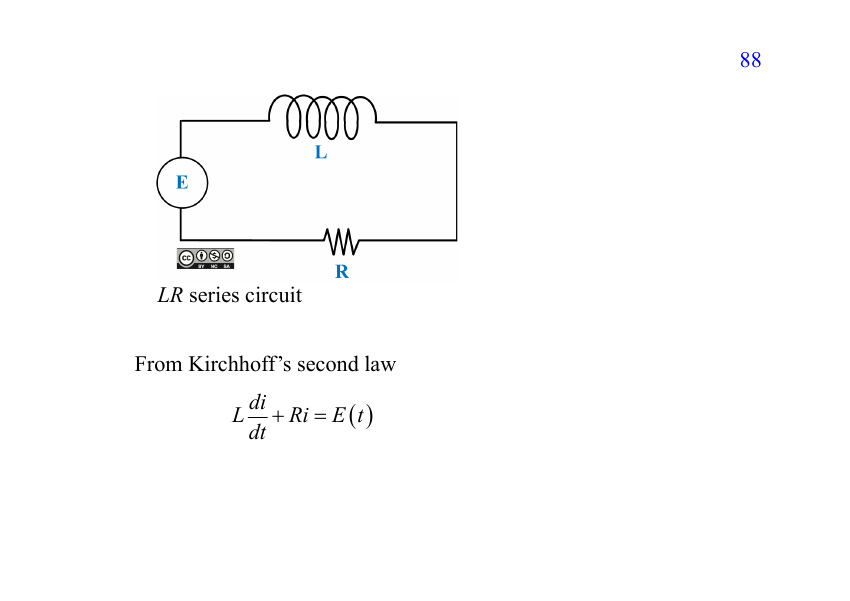

An inductor and resistor in series satisfy
$$ \boxed{L\frac{di}{dt} + Ri = E(t).} $$
For constant $L > 0$, divide by $L$ and use integrating factor $e^{Rt/L}$.

For a constant source $E_0$ and $R > 0$,
$$ i(t) = \frac{E_0}{R} + \left(i(0) - \frac{E_0}{R}\right)e^{-Rt/L}. $$
The time constant is $\tau = L/R$.

### RC series circuit

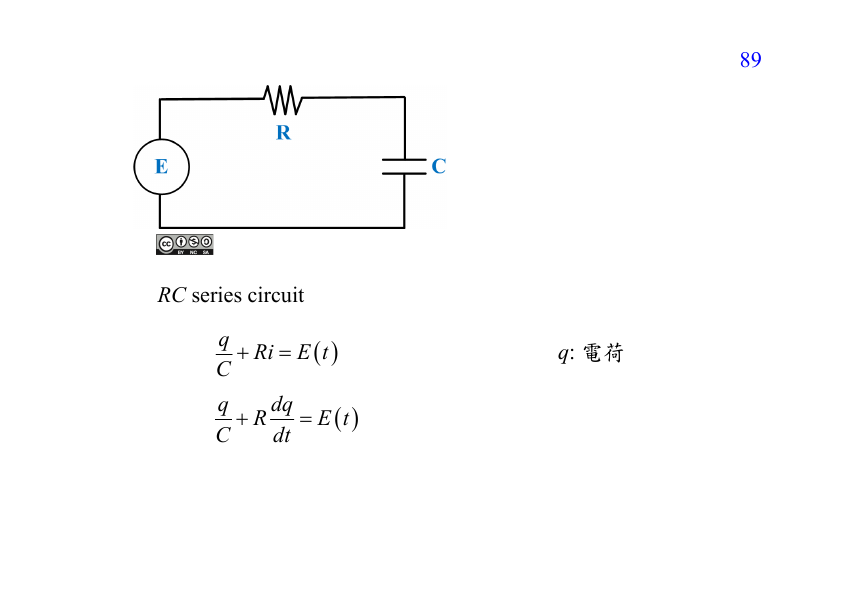

A resistor and capacitor in series satisfy
$$ \frac qC + Ri = E(t), \qquad i = q', $$
so
$$ \boxed{R\frac{dq}{dt} + \frac qC = E(t).} $$
For positive constant $R, C$ and a constant source $E_0$,
$$ q(t) = CE_0 + [q(0) - CE_0]e^{-t/(RC)}. $$
The time constant is $\tau = RC$.

### LRC series circuit

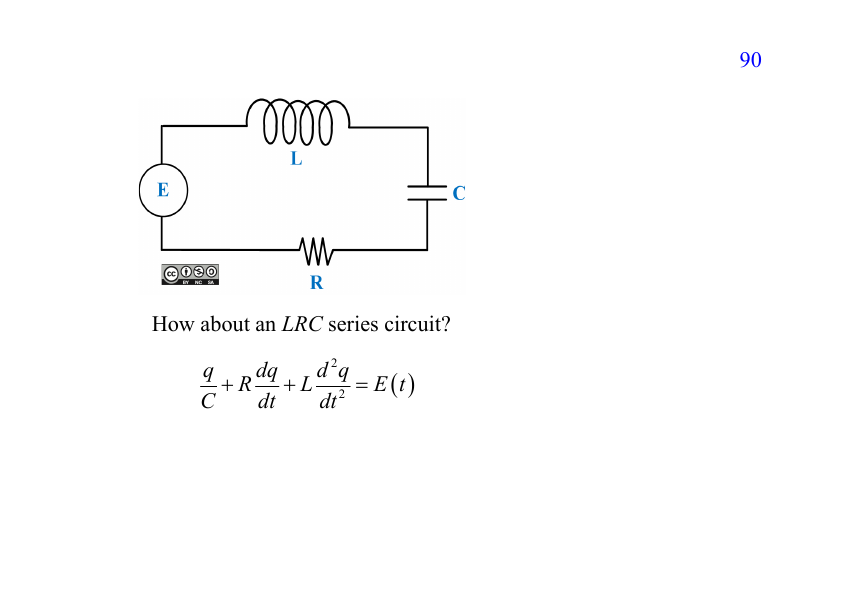

With all three components,
$$ \boxed{L\frac{d^2q}{dt^2} + R\frac{dq}{dt} + \frac qC = E(t).} $$
Since $i = q'$, the inductor introduces a second derivative of charge.  
This is a **second-order** linear equation, requiring two initial conditions  
when $L \ne 0$.

### Example 7: switching on an LR circuit

Take $E = 12$ V, $L = 1/2$ H, $R = 10\ \Omega$, and $i(0) = 0$:
$$ \frac12 i' + 10i = 12 \quad\Longrightarrow\quad i' + 20i = 24. $$
Multiply by $e^{20t}$:
$$ (e^{20t}i)' = 24e^{20t}. $$
Integration gives $i = 6/5 + Ce^{-20t}$.

The initial current gives $C = -6/5$, hence
$$ \boxed{i(t) = \frac65(1 - e^{-20t})\ \mathrm A.} $$
The current approaches $1.2$ A and the time constant is $0.05$ s.

At switching, the inductor limits how fast current changes.  
At constant-source steady state, $i' = 0$ and the resistor sets $i = E/R$.

For an RC circuit under a constant source, charge approaches $CE_0$  
and current approaches zero.  
The resistor and capacitor together determine the charging timescale $RC$.

For either circuit, separate the decaying term from the long-term response.

## 3.2 Nonlinear Models

### The logistic equation

Exponential growth assumes a constant per-capita growth rate.  
To account for limited resources, let that rate decrease with population:
$$ \boxed{P' = P(a - bP) = aP\left(1 - \frac PK\right), \qquad K = \frac ab.} $$
Assume $a > 0$, $b > 0$.  
The number $K$ is the **carrying capacity**.

The equilibria are $P = 0$ and $P = K$.

- If $0 < P < K$, then $P' > 0$.
- If $P > K$, then $P' < 0$.
- Near $P = 0$, a small positive population grows away from zero.

Thus $K$ is stable and $0$ is unstable.  
For $P_0 > 0$, the solution approaches $K$ as $t \to \infty$.

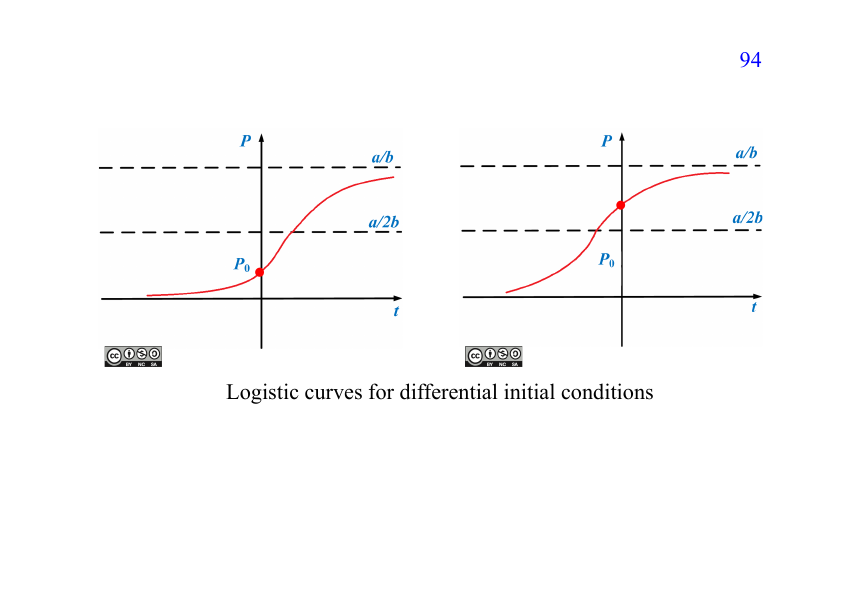

### Solving the logistic equation

For a non-equilibrium solution, separate:
$$ \frac{dP}{P(a - bP)} = dt. $$
Use
$$ \frac{1}{P(a - bP)} = \frac{1/a}{P} + \frac{b/a}{a - bP}. $$
After integration,
$$ \frac1a\ln|P| - \frac1a\ln|a - bP| = t + C. $$

Exponentiating gives
$$ \frac{P}{a - bP} = C_1e^{at}. $$
With $P(0) = P_0$, the result can be written as
$$ \boxed{P(t) = \frac{aP_0}{bP_0 + (a - bP_0)e^{-at}}.} $$
For $P_0 > 0$, this is equivalently
$$ \boxed{P(t) = \frac{K}{1 + (K/P_0 - 1)e^{-at}}.} $$
The first form also includes $P_0 = 0$; both include $P_0 = K$ where defined.

Differentiate the rate to locate an inflection point:
$$ P'' = (a - 2bP)P'. $$
A growing solution with $0 < P < K$ changes concavity at $P = K/2$.  
If $P_0 > K/2$, that point lies before $t = 0$.

A solution beginning above $K$ decreases toward $K$.

### Example 1: spread of a virus on a campus

A closed campus contains 1000 students. Initially one is infected.  
Assume the spread rate is proportional to both the infected population  
and the population not yet infected, with no recovery during the modeled period.

Let $x(t)$ be the infected count, with $t$ in days:
$$ x' = kx(1000 - x), \qquad x(0) = 1, \qquad x(4) = 50. $$
Find $x(6)$.

Use the logistic formula with $K = 1000$:
$$ x(t) = \frac{1000}{1 + 999e^{-1000kt}}. $$
The observation after four days gives
$$ 50 = \frac{1000}{1 + 999e^{-4000k}}, $$
$$ e^{-4000k} = \frac{19}{999}, \qquad 1000k = \frac14\ln\frac{999}{19}. $$

Therefore,
$$ \boxed{x(t) = \frac{1000}{1 + 999e^{-rt}}, \qquad r = \frac14\ln\frac{999}{19} \approx 0.9906\ \mathrm{day}^{-1}.} $$
At six days,
$$ \boxed{x(6) \approx 276\text{ students}.} $$
The model treats population as continuous; round only when reporting a count.

In [3]:
import math
r = math.log(999 / 19) / 4
infected = lambda days: 1000 / (1 + 999 * math.exp(-r * days))
print(f'r = {r:.6f} per day')
print(f'x(0) = {infected(0):.0f}, x(4) = {infected(4):.0f}')
print(f'x(6) = {infected(6):.3f} students')

r = 0.990579 per day
x(0) = 1, x(4) = 50
x(6) = 276.222 students


### Variants of the logistic model

| Model | Interpretation |
|---|---|
| $P' = P(a - bP) + h$ | Constant immigration |
| $P' = P(a - bP) - h$ | Constant emigration or harvesting |
| $P' = P(a - bP) - cP$ | Emigration proportional to population |
| $P' = P(a - bP) + ce^{-kP}$ | Immigration decreases as population rises |

For each model, find equilibria from $P' = 0$ and inspect the sign of $P'$.

### The Gompertz equation

Another limited-growth model is
$$ P' = P(a - b\ln P) = bP\ln\frac KP, \qquad K = e^{a/b}, \qquad P > 0. $$
The per-capita growth rate is proportional to $\ln(K/P)$.

Set $u = \ln P$. Then
$$ u' = a - bu, $$
which is linear even though the original equation is nonlinear.

For $b > 0$ and $P(0) = P_0 > 0$,
$$ u(t) = \frac ab + \left(\ln P_0 - \frac ab\right)e^{-bt}, $$
so
$$ \boxed{P(t) = K\exp\left[\ln\left(\frac{P_0}{K}\right)e^{-bt}\right].} $$
The population approaches $K$.

### Chemical reaction rates

Consider a reaction $A + B \to C$.  
Let $x(t)$ be the amount of product formed, with $x(0) = 0$.

- Initially there are amounts $a$ of $A$ and $b$ of $B$.
- Making one unit of product consumes $s_1$ units of $A$ and $s_2$ units of $B$.
- The remaining reactant amounts are $a - s_1x$ and $b - s_2x$.
- Assume constant volume and a rate proportional to their product.

The model is
$$ \boxed{\frac{dx}{dt} = k(a - s_1x)(b - s_2x), \qquad k > 0.} $$
It is separable:
$$ \int \frac{dx}{(a - s_1x)(b - s_2x)} = kt + C. $$
The physically meaningful range is
$$ 0 \le x \le \min\left(\frac a{s_1}, \frac b{s_2}\right), $$
assuming positive initial amounts and positive consumption coefficients.

If $D = as_2 - bs_1 \ne 0$, partial fractions give
$$ \frac1D\ln\left|\frac{a - s_1x}{b - s_2x}\right| = kt + C. $$
If $D = 0$, write $\alpha = a/s_1 = b/s_2$ instead:
$$ x' = ks_1s_2(\alpha - x)^2. $$
Each case can be integrated, and the limiting reactant determines  
the maximum amount of product.

## Checking Worked Solutions with SymPy

Substitution checks the algebra of a proposed solution.  
Domain restrictions, branch choices, and model assumptions still need to be checked separately.

In [4]:
checks = [
    sp.diff(C * (1 + x), x) * (1 + x) - C * (1 + x),
    sp.diff(-2 + C * sp.exp(3 * x), x) - 3 * (-2 + C * sp.exp(3 * x)) - 6,
]
y_linear = (x**5 - x**4) * sp.exp(x) + C * x**4
checks.append(x * sp.diff(y_linear, x) - 4 * y_linear - x**6 * sp.exp(x))
for residual in checks:
    assert sp.simplify(residual) == 0
print('Three differential-equation residuals simplify to zero.')

Three differential-equation residuals simplify to zero.


In [5]:
A = 250 - 225 * sp.exp(-t / 100)
T = 21 + 128 * sp.exp(-sp.log(2) * t / 3)
i = sp.Rational(6, 5) * (1 - sp.exp(-20 * t))
assert sp.simplify(sp.diff(A, t) - (sp.Rational(5, 2) - A / 100)) == 0
assert sp.simplify(sp.diff(T, t) + sp.log(2) * (T - 21) / 3) == 0
assert sp.simplify(sp.diff(i, t) / 2 + 10 * i - 12) == 0
assert (A.subs(t, 0), T.subs(t, 0), T.subs(t, 3), i.subs(t, 0)) == (25, 149, 85, 0)
print('Mixing, cooling, and LR solutions satisfy the equations and given data.')

Mixing, cooling, and LR solutions satisfy the equations and given data.


## Homework Due Sunday

Due: 6 a.m.

### 1. Find a substitution for linearity

If $z_1$ and $z_2$ solve the same homogeneous linear equation $z' = a(x)z$,  
then $z_1 + z_2$ also solves it:  
the solution set is **closed under addition**.

A change of dependent variable can turn this addition into another operation.  

For each nonlinear DE below, find an invertible substitution $z = \phi(y)$  
that transforms it into a homogeneous linear DE in $z$.  
Show your chain-rule calculation and state the transformed equation.

Don't worry about the domain;  
but use the indicated domain for $y$ when in doubt.

1. $y' = xy\ln y, \qquad y > 0$.
2. $y' = -xy(1 + y), \qquad y > 0$.
3. $y' = \dfrac{x(1 + y^2)}{2y}, \qquad y > 0$.
4. $y' = x\sin y\cos y, \qquad -\pi/2 < y < \pi/2$.

For each equation,  
let $y_1$ and $y_2$ be solutions on a common interval.  
Use your substitution to write the operation
$$ y_1 \star y_2 = \phi^{-1}\bigl(\phi(y_1) + \phi(y_2)\bigr) $$
explicitly in terms of $y_1$ and $y_2$.  

State that this produces another solution in the indicated domain.

### 2. Find a nonlinear DE fomr a substitution

Reverse the process.  
For each substitution below, construct a nonlinear DE for $y(x)$ that becomes
$$ z' = xz. $$
Use the chain rule to derive an explicit formula for $y'$ and $y$ to satisfy.  
Then find the binary operation such that the solution space is closed under that.

1. $z = \ln(1 + y), \qquad y > -1$.
2. $z = \sinh y, \qquad y \in \mathbb R$.
3. $z = \dfrac{y}{1 - y}, \qquad 0 < y < 1$.
4. $z = y + \dfrac1y, \qquad y > 1$.

For item 2, recall $\sinh y = (e^y - e^{-y})/2$ and  
$\dfrac{d}{dy}\sinh y = \cosh y = (e^y + e^{-y})/2$.  

For item 4, solve a quadratic equation to find the inverse branch.

## Homework Due Wednesday

Due: 6 a.m.

### Riccati nonlinear superposition: a ternary operation

A classical example in Lie's theory of nonlinear superposition  
is the **Riccati equation**:
$$ y'(x) = a(x) + b(x) y(x) + c(x) y(x)^2. $$
Here $a$, $b$, and $c$ are continuous, with $c$ not identically zero.  

Reference: [Ballesteros et al., *From constants of motion to superposition rules for Lie–Hamilton systems*, Section 3](https://lbt.usal.es/wp-content/uploads/2015/11/Fromconstants.pdf).

**(a) One pair of difference**

Let $u(x)$ and $v(x)$ be two distinct solutions of the same Riccati equation.
On a common interval where $u - v \ne 0$.
Prove that
$$ \frac{d}{dx}\ln|u - v| = b + c(u + v). $$

**(b) The corss ratio**

Let $s(x)$, $t(x)$, $u(x)$, and $v(x)$ be four pairwise distinct solutions  
of the same Riccati equation on a common interval.

Their **cross ratio**
$$ R(x) = \frac{(s - t)(u - v)}{(s - v)(u - t)} $$
is constant with respect to $x$.  
Prove this result using part (a).

**(c) Ternary operator?**

Given three distinct solutions $y_1(x)$, $y_2(x)$, and $y_3(x)$,  
set $(s, t, u, v) = (y, y_1, y_2, y_3)$ in part (b) to obtain  
$$ \frac{(y - y_1)(y_2 - y_3)}{(y - y_3)(y_2 - y_1)} = K, $$
where $K$ is a constant we can choose.

Solve this relation algebraically for $y$  
in terms of $y_1$, $y_2$, $y_3$, and $K$.
Verify that your formula solves the same Riccati equation wherever defined.

What choices of $K$ forces $y$ to approach/recover the three known solutions?

**(d) An example**

Consider $y' = y^2$.  
On $x > 0$, verify the three solutions
$$ y_1 = 0, \qquad y_2 = -\frac1x, \qquad y_3 = -\frac1{x + 1}. $$

Use the formula from part (c) to construct a fourth solution  
satisfying $y(1) = -2/3$.  
Determine $K$ and write your solution explicitly.  
Check both the differential equation and the initial condition.